# Analisis de supervivencia del tiempo hasta el abandono en una cohorte de estudiantes


## Resumen ejecutivo

**Contexto.** Una oficina de investigacion institucional de una universidad de cuatro anos quiere entender *cuando*, y no solo *si*, los estudiantes abandonan. Se hace seguimiento a una cohorte de nuevo ingreso periodo a periodo desde la matriculacion; algunos se graduan, algunos abandonan y unos pocos siguen matriculados cuando se cierra la ventana de observacion. Como el resultado de los estudiantes aun matriculados es desconocido (censurado por la derecha), y como la graduacion retira a un estudiante del grupo en riesgo sin ser un abandono, una regresion ordinaria de aprobado/reprobado descarta la informacion de tiempo y sesga cualquier estimacion que ignore la censura. La herramienta adecuada es el **analisis de tiempo hasta el evento (supervivencia)**, donde el evento de interes es el **abandono** y el reloj se mide en periodos academicos matriculados.

**Pregunta de negocio.** ¿La **situacion academica del primer periodo** de un estudiante (una senal de alerta temprana) separa las trayectorias de tiempo hasta el abandono de la cohorte, y que caracteristicas del estudiante impulsan el riesgo de abandono tras el ajuste? Las respuestas alimentan un sistema de alerta temprana: los estudiantes cuyo riesgo estimado de abandono es alto deberian recibir acompanamiento en sus primeros periodos, cuando la intervencion es mas barata y mas efectiva.

**Enfoque.** Simulamos una cohorte de 100 estudiantes en linea (sin datos externos), y luego recorremos un flujo de trabajo de supervivencia estandar:

1. **PROC MEANS** perfila los predictores a traves de los tres resultados observados (Graduado / Abandono / aun Matriculado) para confirmar que la senal simulada se comporta de forma sensata.
2. **PROC FREQ** tabula de forma cruzada la situacion academica del primer periodo frente al resultado con una prueba chi-cuadrado de asociacion.
3. **PROC UNIVARIATE** informa percentiles robustos del tiempo hasta el abandono por situacion.
4. **PROC LIFETEST** estima curvas de abandono de Kaplan-Meier estratificadas por situacion y ejecuta pruebas de igualdad **log-rank** y **Wilcoxon**.
5. **PROC PHREG** ajusta un modelo multivariable de **riesgos proporcionales de Cox** para el riesgo de abandono, con un efecto `CLASS` codificado por referencia, manejo de empates de Efron e intervalos de confianza de limite de riesgo.

**Que muestran los datos.** De los 100 estudiantes simulados, **49 abandonaron, 49 se graduaron y 2 permanecieron matriculados** en el corte de 12 periodos. Los estudiantes senalados con **advertencia academica** en su primer periodo (GPA del primer periodo por debajo de 2.5) abandonan mucho mas rapido que los estudiantes en buena situacion: mediana del tiempo hasta el abandono de **3.8 periodos frente a 8.7 periodos**, una separacion que la prueba log-rank confirma (chi-cuadrado = 10.73, *p* = 0.0011). El modelo de Cox identifica el GPA del primer periodo (razon de riesgo 0.21 por punto de GPA, *p* < 0.0001), el GPA de la secundaria (HR 0.45, *p* = 0.027) y la condicion de primera generacion (HR 2.03, *p* = 0.031) como impulsores ajustados significativos del abandono, mientras que la condicion de beca Pell no es significativa una vez que se controla el GPA (HR 0.95, *p* = 0.85).

> *Todas las cifras son ilustrativas y se generan a partir de datos sinteticos; no son registros reales de estudiantes. Este entorno funciona sin licencia, por lo que la cohorte se dimensiona en 100 estudiantes.*


## Fuentes de datos

Todos los datos son **sinteticos**, generados en linea en el primer paso DATA con `CALL STREAMINIT(20260611)` y la funcion `RAND`. Sin archivos externos ni acceso a la red. Una fila por estudiante simulado.

**Conjunto de datos `enrollments`** (100 filas, una fila por estudiante)

| Variable | Tipo | Descripcion | Distribucion generadora |
|----------|------|-------------|--------------------------|
| `student_id` | Num | Clave unica del estudiante | secuencia 1–100 |
| `first_gen` / `first_gen_lbl` | Num / Char | Indicador de primera generacion (0/1) y etiqueta | Bernoulli, ~42% |
| `pell` | Num | Indicador de beca Pell (necesidad financiera) (0/1) | Bernoulli, ~42% |
| `program` | Char | STEM / BUS / HUM | categorica (~42% / 32% / 26%) |
| `hs_gpa` | Num | GPA de secundaria (1.8–4.0) | Normal(3.00, 0.42), acotada |
| `term1_gpa` | Num | GPA universitario del primer periodo (0–4.0) | f(hs_gpa, program) + ruido Normal |
| `standing` | Char | Situacion academica del primer periodo | `term1_gpa < 2.5` → Advertencia academica, en caso contrario Buena situacion |
| `time_terms` | Num | Periodos matriculados hasta el evento o la censura | sorteos Weibull en competencia; limitado a 12 |
| `dropped` | Num | Indicador del evento de abandono (1 = abandono, 0 = censurado) | derivado |
| `outcome` | Char | Graduado / Abandono / Matriculado | derivado de sorteos en competencia |

Un predictor lineal latente en la escala logaritmica vincula la **tasa de abandono** de cada estudiante con el GPA del primer periodo, el GPA de secundaria, la condicion de primera generacion y la necesidad financiera, de modo que los predictores llevan una senal genuina pero ruidosa. El abandono y la graduacion se sortean como tiempos latentes **en competencia** (Weibull); lo que ocurra primero dentro de una ventana de 12 periodos se convierte en el resultado observado, y los estudiantes que llegan al periodo 12 sin ninguno de los dos son censurados por la derecha. Para los modelos de supervivencia el **evento es el abandono** (`dropped = 1`); tanto la graduacion como la matricula en curso se tratan como censura (`dropped = 0`).


## 1. Simular la cohorte de estudiantes

La primera celda construye una cohorte sintetica de 100 estudiantes. Un predictor lineal latente en la escala logaritmica vincula la tasa de abandono de cada estudiante con el GPA del primer periodo, el GPA de secundaria, la condicion de primera generacion y la condicion Pell. El abandono y la graduacion se generan como tiempos latentes **en competencia** (sorteos Weibull); lo que ocurra primero dentro de una ventana de observacion de 12 periodos se convierte en el resultado observado, y los estudiantes que llegan al periodo 12 sin abandonar ni graduarse son censurados por la derecha. Un GPA del primer periodo por debajo de 2.5 senala al estudiante con **advertencia academica**: la senal de alerta temprana que probamos en el paso de supervivencia. Los sorteos aleatorios usan `CALL STREAMINIT` para la reproducibilidad y la funcion `RAND` en las distribuciones Uniforme, Normal y Weibull. Pisos y acotaciones estrictos mantienen todos los valores plausibles (GPA en 0–4.0).


In [1]:
DATOS matriculas;
    LLAMAR streaminit(20260611);
    LONGITUD situacion $16 primera_gen_lbl $16 programa $4 resultado $12;
    HACER id_estudiante = 1 HASTA 100;
        /* Indicadores de primera generacion y necesidad economica */
        primera_gen = (rand("uniform") < 0.42);
        SI primera_gen ENTONCES primera_gen_lbl = "Primera generacion";
        SINO              primera_gen_lbl = "Generacion continua";
        pell = (rand("uniform") < 0.42);

        /* Programa de estudios */
        v = rand("uniform");
        SI      v < 0.42 ENTONCES programa = "STEM";
        SINO SI v < 0.74 ENTONCES programa = "BUS";
        SINO                  programa = "HUM";

        /* Preparacion academica y rendimiento del primer periodo */
        gpa_bach = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        gpa_term1 = round(MIN(4.0, MAX(0.0,
                     0.55*gpa_bach + 1.05 + 0.12*(programa="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Senal de alerta temprana: GPA del primer periodo por debajo de 2.5 = alerta academica */
        SI gpa_term1 < 2.5 ENTONCES situacion = "Alerta academica";
        SINO                    situacion = "Buena situacion";

        /* Riesgo latente de abandono en la escala logaritmica: menor GPA,
           primera generacion y condicion Pell elevan la tasa de abandono. */
        eta = -1.05
             - 1.45*(gpa_term1 - 2.8)
             - 0.55*(gpa_bach - 3.0)
             + 1.05*primera_gen
             + 0.45*pell;
        tasa_abandono = EXP(eta);

        /* Tiempos latentes en competencia (periodos): abandono vs graduacion */
        t_abandono = rand("weibull", 1.2, 7.0) / MAX(0.30, tasa_abandono);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(gpa_term1 - 2.8));

        /* Ventana de censura administrativa de 12 periodos */
        censura_en = 12;
        SI t_abandono <= t_grad AND t_abandono <= censura_en ENTONCES HACER;
            resultado = "Abandonado";   abandono = 1; tiempo_periodos = t_abandono;
        END;
        SINO SI t_grad < t_abandono AND t_grad <= censura_en ENTONCES HACER;
            resultado = "Graduado"; abandono = 0; tiempo_periodos = t_grad;
        END;
        SINO HACER;
            resultado = "Matriculado";  abandono = 0; tiempo_periodos = censura_en;
        END;
        tiempo_periodos = round(tiempo_periodos, 0.1);
        SALIDA;
    END;
    MANTENER id_estudiante primera_gen primera_gen_lbl pell programa gpa_bach
         gpa_term1 situacion tiempo_periodos abandono resultado;
EJECUTAR;


NOTE: DATA matriculas


NOTE: Wrote matriculas (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Perfilar los predictores por resultado observado

Antes de modelar, confirmamos que los predictores simulados se mueven en las direcciones esperadas. **PROC MEANS** informa el conteo, la media, la dispersion y el rango de cada predictor numerico dentro de los tres resultados observados.

La cohorte se divide en **49 Graduados / 49 Abandonos / 2 aun Matriculados**. Los graduados tienen un GPA del primer periodo mas alto (media **2.94** frente a **2.54** de los estudiantes que abandonaron) y un GPA de secundaria mas alto (**3.10** frente a **2.90**): exactamente el gradiente de preparacion academica que el analisis espera. Los dos estudiantes aun matriculados se ubican exactamente en el techo de censura de 12 periodos en `time_terms` (media 12.00, desviacion estandar 0), la censura por la derecha que un analisis de desercion debe respetar. Entre los estudiantes que abandonaron, el evento llega temprano: media de **3.31 periodos**, con un rango de 0.1 a 8.9.


In [2]:
PROCEDIMIENTO MEDIAS DATOS=matriculas n mean std MIN MAX maxdec=2;
    CLASE resultado;
    VAR gpa_bach gpa_term1 tiempo_periodos;
    ETIQUETA gpa_bach="GPA bachillerato" gpa_term1="GPA primer periodo"
        tiempo_periodos="Periodos hasta el evento" resultado="Resultado";
EJECUTAR;

                                                  The MEANS Procedure

                                     Analysis Variable : gpa_bach GPA bachillerato

        Resultado            N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        Abandonado              49           2.90           0.45           2.01           3.89
        Graduado                49           3.10           0.46           1.97           4.00
        Matriculado              2           3.10           0.17           2.98           3.22
        --------------------------------------------------------------------------------------

                                    Analysis Variable : gpa_term1 GPA primer periodo

        Resultado            N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. ¿La senal de alerta temprana sigue al resultado?

El sistema de alerta temprana senala con **advertencia academica** a cualquier estudiante cuyo GPA del primer periodo caiga por debajo de 2.5. **PROC FREQ** tabula de forma cruzada esa senal frente al resultado observado y ejecuta una prueba chi-cuadrado de asociacion. Suprimimos los porcentajes de fila, columna y globales (`NOROW NOCOL NOPERCENT`) para que la tabla muestre los conteos brutos, y anadimos frecuencias unidireccionales de `standing` y de la condicion de primera generacion para la composicion de la cohorte.

La tabla cruzada es contundente: de los **29** estudiantes senalados con advertencia academica, **21 abandonaron** y solo 8 se graduaron; de los **71** en buena situacion, **41 se graduaron** y 28 abandonaron. La asociacion es significativa (chi-cuadrado = 9.21, gl = 2, *p* = 0.0100; V de Cramer = 0.30). Observe la **advertencia que se imprime junto a ella**: con 100 estudiantes y una delgada columna de "Matriculado" de dos graduados, un tercio de las celdas de la tabla tienen conteos esperados por debajo de 5, por lo que el valor *p* del chi-cuadrado es fragil aqui. Esa fragilidad es precisamente por lo que las pruebas de supervivencia de las secciones siguientes, que usan la informacion completa de tiempo en lugar de una tabla 3×2, son la prueba mas confiable del efecto de la situacion.


                                                   The FREQ Procedure

Table of situacion by resultado

situacion        | Abandonado |   Graduado |Matriculado |       Total
-----------------+------------+------------+------------+------------
Alerta academica |         21 |          8 |          0 |          29
-----------------+------------+------------+------------+------------
Buena situacion  |         28 |         41 |          2 |          71
-----------------+------------+------------+------------+------------
Total            |         49 |         49 |          2 |         100

Statistics for Table of situacion by resultado

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2904


           


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_situacion_resultado.spec.json
NOTE: ODS plot written: freq_situacion.spec.json
NOTE: ODS plot written: freq_primera_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


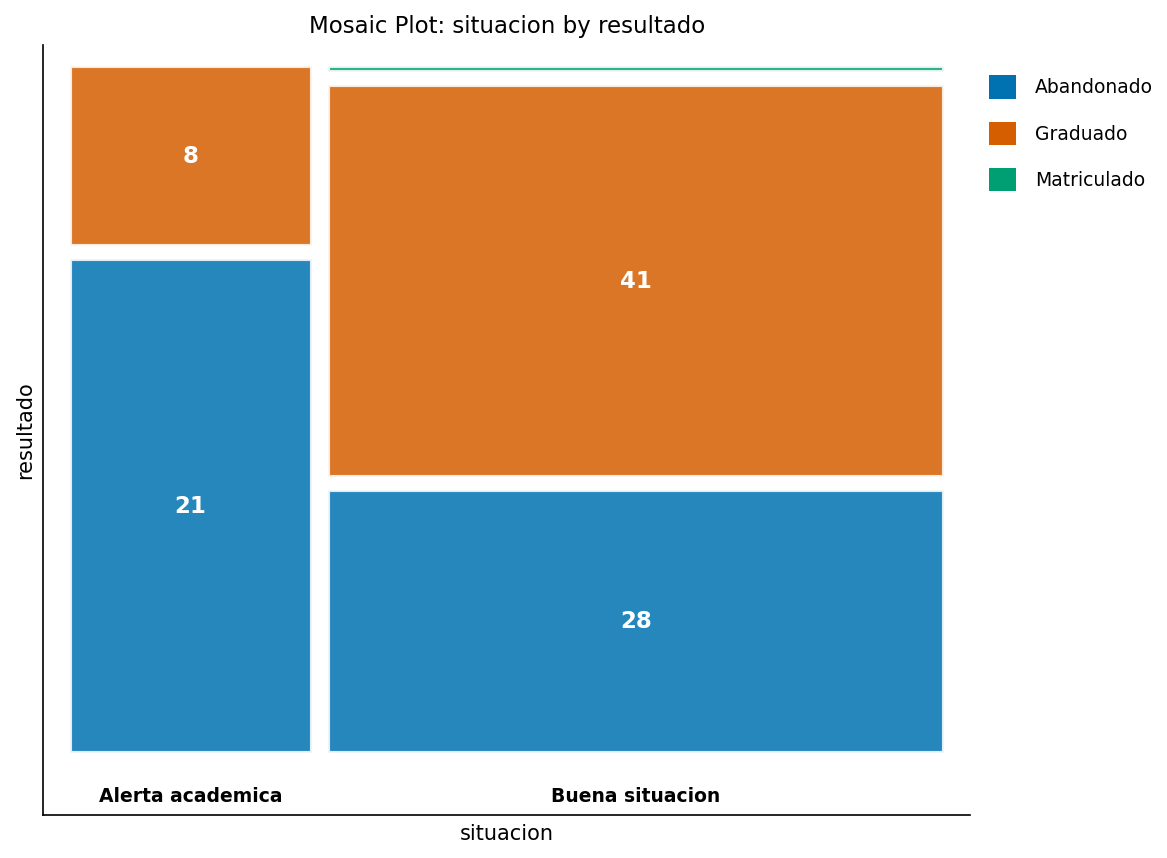

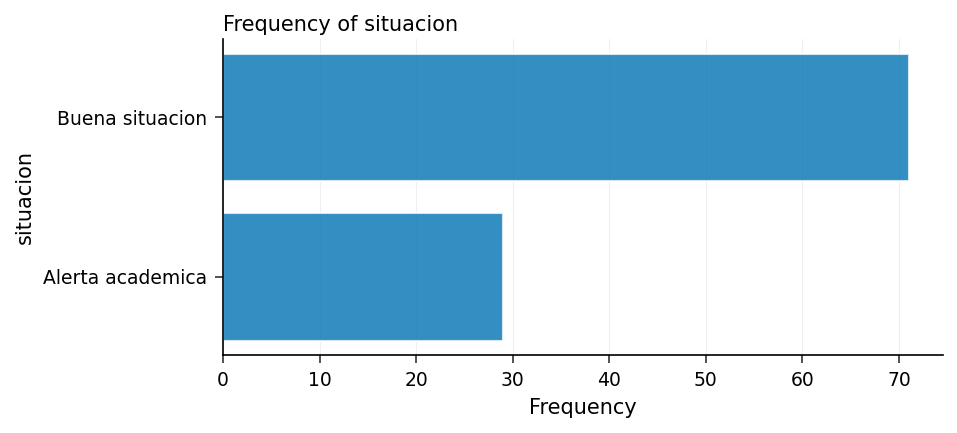

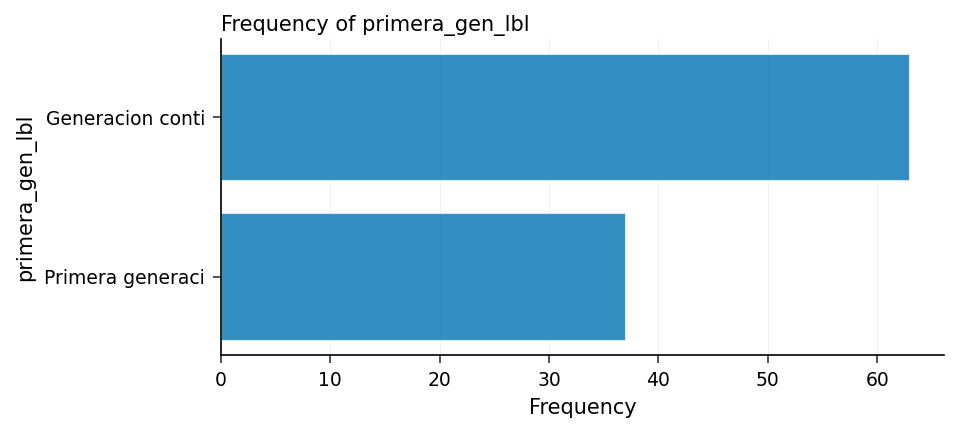

In [3]:
PROCEDIMIENTO FRECUENCIAS DATOS=matriculas;
    TABLES situacion*resultado / chisq norow nocol nopercent;
    TABLES situacion primera_gen_lbl;
EJECUTAR;

## 4. ¿Cuando ocurren los abandonos? Percentiles por situacion

Para los estudiantes que realmente abandonaron, ¿*cuando* se fueron? **PROC UNIVARIATE** (restringido a `dropped = 1`) informa los percentiles 10, 50 (mediana) y 90 del tiempo hasta el abandono dentro de cada grupo de situacion, escritos en un conjunto de datos de salida que luego imprimimos. Esto describe la dispersion del momento del abandono sin suponer una distribucion.

La mediana del abandono entre los estudiantes que se fueron ocurre alrededor del periodo **2.4** (advertencia academica) frente a **2.6** (buena situacion): cercanas porque *condicional al abandono*, ambos grupos tienden a irse temprano. Por lo tanto, el efecto de la situacion no tiene que ver principalmente con *cuando* ocurre un abandono, sino con *cuantos* estudiantes abandonan y con que rapidez se adelgaza el grupo en riesgo, que es precisamente lo que capturan las curvas de Kaplan-Meier de la siguiente seccion.


In [4]:
PROCEDIMIENTO UNIVARIATE DATOS=matriculas NOPRINT;
    DONDE abandono = 1;
    CLASE situacion;
    VAR tiempo_periodos;
    SALIDA out=ref_abandono pctlpts=10 50 90 pctlpre=t_ p=;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=ref_abandono noobs ETIQUETA;
    TÍTULO "Percentiles del tiempo hasta el abandono (periodos), por situacion academica";
EJECUTAR;
TÍTULO;

                      Percentiles del tiempo hasta el abandono (periodos), por situacion academica                      

       SITUACION  T_10  T_50  T_90
Alerta academica   0.2   2.4   7.9
Buena situacion    0.4   2.6   8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset ref_abandono has 2 observations and 4 variables.
NOTE: PROC PRINT data=ref_abandono

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Curvas de abandono de Kaplan-Meier por situacion academica

Ahora el paso central de supervivencia. **PROC LIFETEST** estima la funcion de supervivencia no parametrica de **Kaplan-Meier** para el *tiempo hasta el abandono*, tratando la graduacion y la matricula en curso como censura (`dropped(0)` marca las observaciones censuradas). Estratificar por `standing` produce una curva de abandono por grupo, y `TEST=(LOGRANK WILCOXON)` ejecuta dos pruebas complementarias de si esas curvas difieren: la prueba **log-rank** pondera todos los tiempos de evento por igual (sensible a diferencias tardias), mientras que la prueba **Wilcoxon** da mayor peso a los tiempos de evento tempranos (sensible a la desercion temprana). `PLOTS=SURVIVAL` solicita el grafico superpuesto de curvas de supervivencia.

En toda la cohorte hay **49 eventos de abandono y 51 observaciones censuradas**. Las curvas se separan claramente: los estudiantes en advertencia academica alcanzan una **mediana de supervivencia (tiempo hasta el abandono) de 3.8 periodos**, mientras que los estudiantes en buena situacion duran mas del doble (**8.7 periodos**). Ambas pruebas rechazan la igualdad (**log-rank chi-cuadrado = 10.73, *p* = 0.0011; Wilcoxon chi-cuadrado = 7.66, *p* = 0.0056**) y los estadisticos comparables nos dicen que la brecha se sostiene a lo largo de toda la ventana de matricula, no solo un pico temprano. El grafico hace el mensaje inmediato: la curva naranja de advertencia academica cae abruptamente durante los primeros cuatro periodos, mientras que la curva azul de buena situacion permanece alta.


    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: situacion = Alerta academica

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804             


NOTE: PROC LIFETEST data=matriculas

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


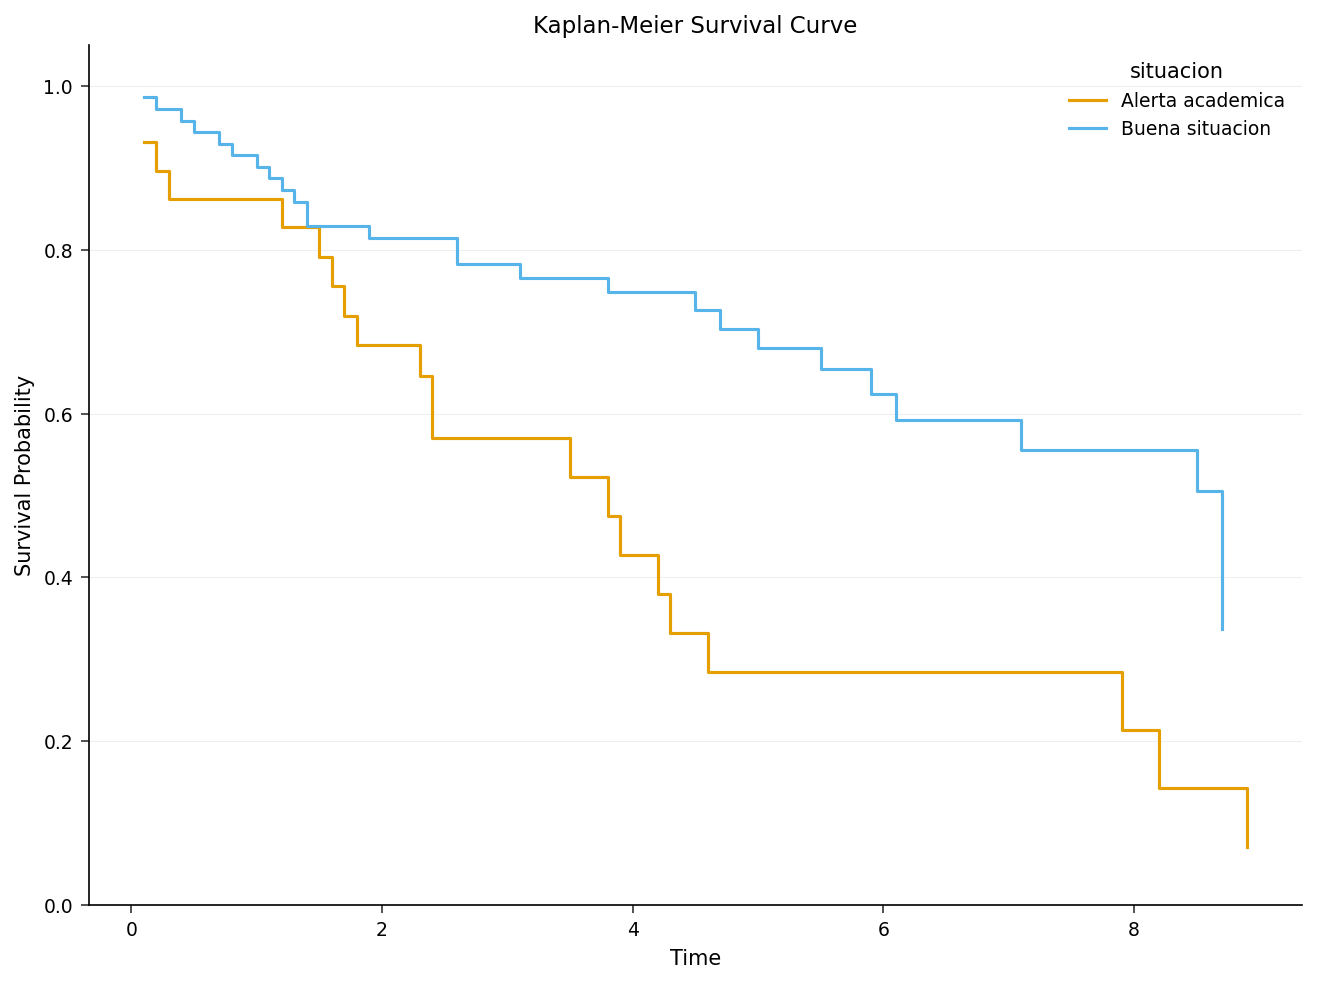

In [5]:
PROCEDIMIENTO LIFETEST DATOS=matriculas PLOTS=SURVIVAL METHOD=km;
    TIME tiempo_periodos*abandono(0);
    STRATA situacion / TEST=(logrank WILCOXON);
EJECUTAR;

## 6. Modelo multivariable de riesgos proporcionales de Cox para el abandono

**PROC PHREG** ajusta el modelo de **riesgos proporcionales de Cox** para el riesgo de abandono, ajustando los predictores simultaneamente. Solicitudes clave:

- `dropped(0)` hace del **abandono** el evento y de todo lo demas censura.
- `CLASS first_gen_lbl (ref="Continuing-gen") / param=ref` codifica por referencia el factor de primera generacion, de modo que su razon de riesgo se lee frente a los estudiantes de generacion continua.
- `TIES=EFRON` es la aproximacion de manejo de empates recomendada cuando varios estudiantes se van en el mismo periodo.
- `RL` anade intervalos de confianza de la razon de riesgo (limite de riesgo).
- La sentencia `HAZARDRATIO` informa el contraste de primera generacion frente al grupo de referencia.

Una razon de riesgo por encima de 1 significa un abandono *mas rapido* (mayor riesgo); por debajo de 1 significa un abandono *mas lento* (protector).


In [6]:
PROCEDIMIENTO PHREG DATOS=matriculas;
    CLASE primera_gen_lbl (REF="Generacion continua") / PARAM=REF;
    MODELO tiempo_periodos*abandono(0) = gpa_bach gpa_term1 primera_gen_lbl pell
          / TIES=efron rl;
    ETIQUETA gpa_bach="GPA bachillerato" gpa_term1="GPA primer periodo"
        primera_gen_lbl="Primera generacion" pell="Pell";
    hazardratio "Primera generacion vs continua" primera_gen_lbl / DIFF=REF;
EJECUTAR;

              The PHREG Procedure              

Criterion                                 Value
----------------------  -----------------------
Number of Observations                      100
Number of Events                             49
-2 LOG L                                352.608
Ties Handling                             efron
Convergence Status      0 Converged (penalized)

                                               Analysis of Maximum Likelihood Estimates                                               

Parameter                               DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
--------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
GPA bachillerato                         1  -0.80941         0.36662      4.8743      0.0273         0.445         0.217         0.913
GPA primer periodo                       1  -1.56957         0.38434     


NOTE: PROC PHREG data=matriculas

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretacion y proximos pasos

**Lectura de la salida, de principio a fin:**

- **PROC MEANS** confirma la senal simulada: los estudiantes que se graduaron tienen un GPA del primer periodo mas alto (2.94 frente a 2.54) y un GPA de secundaria mas alto (3.10 frente a 2.90) que los estudiantes que abandonaron, y los estudiantes aun matriculados se ubican en el techo de 12 periodos: la censura por la derecha que respetan los modelos de supervivencia.
- **PROC FREQ** muestra que la senal de advertencia academica del primer periodo sigue al resultado (21 de 29 estudiantes senalados abandonaron; 41 de 71 estudiantes en buena situacion se graduaron; *p* = 0.0100), a la vez que senala con honestidad que el chi-cuadrado es fragil en una tabla de 100 estudiantes con celdas escasas.
- **PROC UNIVARIATE** muestra que *condicional al abandono*, ambos grupos se van temprano (mediana ~2.4–2.6 periodos); el efecto de la situacion tiene que ver con cuantos estudiantes abandonan y con que rapidez se adelgaza el grupo en riesgo, no con el momento entre quienes se van.
- **PROC LIFETEST** entrega el titular: curvas de abandono de Kaplan-Meier que se separan marcadamente por situacion (mediana 3.8 frente a 8.7 periodos; log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). La senal de alerta temprana es un discriminador genuino y estadisticamente respaldado del momento del abandono.
- **PROC PHREG** cuantifica el efecto ajustado de cada predictor sobre el riesgo de abandono. Tras el ajuste, el **GPA del primer periodo es el factor protector mas fuerte** (razon de riesgo 0.21 por punto de GPA, IC 95% 0.10–0.44, *p* < 0.0001): cada punto adicional de GPA reduce el riesgo de abandono en aproximadamente cuatro quintas partes. El **GPA de secundaria** tambien es protector (HR 0.45, IC 95% 0.22–0.91, *p* = 0.027). Los **estudiantes de primera generacion** enfrentan aproximadamente el doble de riesgo de abandono que sus pares de generacion continua con los mismos GPA (HR 2.03, IC 95% 1.07–3.84, *p* = 0.031). La **condicion Pell no es significativa** una vez que se controla el GPA (HR 0.95, IC 95% 0.53–1.69, *p* = 0.85): un recordatorio util de que un factor de riesgo bruto puede desvanecerse tras el ajuste. La hipotesis nula global se rechaza de forma decisiva (chi-cuadrado de razon de verosimilitud = 31.11 con 4 gl, *p* < 0.0001).

**Como actuaria una institucion con esto.** El modelo de Cox produce un predictor lineal por estudiante (puntaje de riesgo) que ordena la cohorte por riesgo de abandono; los estudiantes de mayor riesgo (GPA bajo del primer periodo combinado con condicion de primera generacion) se derivan al acompanamiento de alerta temprana en sus primeros periodos, cuando la intervencion es mas barata y mas efectiva. La comparacion de Kaplan-Meier da a los asesores un criterio unico y defendible que ya recopilan al final del primer periodo: la situacion academica.

**Advertencias y extensiones.** (1) Esta cohorte sintetica trata la graduacion como censura para el modelo de abandono; con datos reales, la graduacion y el abandono son genuinos **riesgos en competencia**, y una extension de riesgos en competencia (incidencia acumulada) mediante `EVENTCODE=` de PROC PHREG evitaria sobreestimar la probabilidad de abandono. (2) El supuesto de riesgos proporcionales deberia comprobarse (`ASSESS PH` de PHREG o residuos de Schoenfeld) antes de confiar en una unica razon de riesgo a lo largo de todos los periodos. (3) Las covariables que varian en el tiempo (GPA periodo a periodo, cambios en la ayuda financiera, carga de cursos) son comunes en los datos de retencion y las sentencias de programacion de PHREG las manejan de forma natural. (4) La cohorte de 100 estudiantes aqui esta dimensionada al limite de ejecucion sin licencia; un analisis de produccion llevaria varios miles de estudiantes, estrechando cada intervalo de confianza. Valide siempre un puntaje de riesgo implementado en una cohorte de reserva antes de actuar operativamente sobre el.
